In [1]:
from astropy.time import Time
import astropy
import astropy.units as u
import lumos
import lumos.brdf
import lumos.brdf.library as brdf_library
import lumos.brdf.tools
import lumos.calculator
import lumos.conversions
import lumos.functions
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import EarthLocation
from lumos.brdf.library import BINOMIAL, LAMBERTIAN, PHONG
from lumos.geometry import Surface

#from analysis import calculator, streakfunctions
#from gen2_starlink import satellitemodels1


#Load the CSV file
db = pd.read_csv("satellite_observations_all.csv")


#Extract the observer longitude column
longitudes = db['observer_longitude_deg']
latitude = db['observer_latitude_deg']
height = db['observer_altitude_m']
uncert= db['apparent_magnitude_uncertainty']
range_km = db['range_to_sat_km_satchecker']
AP_mag_uncertainty = db['apparent_magnitude_uncertainty']
time = db['observation_time_utc']
alt = db['alt_deg_satchecker']
azi = db['az_deg_satchecker']
phase= db['phase_angle_deg_satchecker']
ob_mode=db['observing_mode']
ra=db['sat_ra_deg_satchecker']
rec=db['sat_dec_deg_satchecker']


In [9]:
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import EarthLocation, AltAz, ICRS
import pandas as pd


def horizontal_to_equatorial(latitude, longitude, elevation, azimuth_deg, elevation_obs_deg, julian_day):
    location = EarthLocation(lat=latitude*u.deg, lon=longitude*u.deg, height=elevation*u.m)
    t = Time(julian_day, format='jd')
    altaz = AltAz(az=azimuth_deg*u.deg, alt=elevation_obs_deg*u.deg, location=location, obstime=t)
    eq = altaz.transform_to(ICRS())
    return eq.ra.deg, eq.dec.deg

Mean RA difference (deg): -0.0040306469164064634
Mean Dec difference (deg): -0.0028356669967750437
Max RA difference (deg): 0.1940754504038864
Max Dec difference (deg): 0.005678071195958978
Std dev RA difference (deg): 0.005250793922141488
Std dev Dec difference (deg): 0.001671523736997002


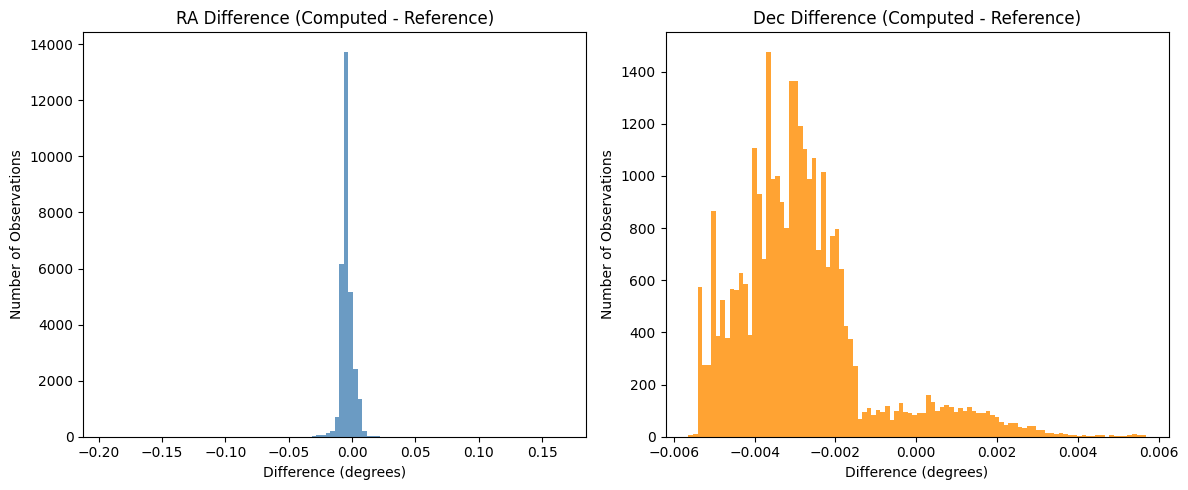

In [14]:
import pandas as pd
import numpy as np
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import EarthLocation, AltAz, ICRS
import matplotlib.pyplot as plt

# Load CSV 
db = pd.read_csv("satellite_observations_all.csv")

# Convert observation_time_utc to datetime with UTC timezone, drop bad entries 
db['observation_time_utc'] = pd.to_datetime(db['observation_time_utc'], utc=True, errors='coerce')
db = db.dropna(subset=['observation_time_utc'])

# Convert to ISO format strings with consistent dtype for astropy
iso_times = db['observation_time_utc'].dt.strftime('%Y-%m-%dT%H:%M:%S').astype(str).to_numpy(dtype='<U')

# Convert ISO times to Julian Dates
db['julian_day'] = Time(iso_times, format='isot', scale='utc').jd

# Define conversion function 
def horizontal_to_equatorial(latitude, longitude, elevation, azimuth_deg, elevation_obs_deg, julian_day):
    try:
        location = EarthLocation(lat=latitude*u.deg, lon=longitude*u.deg, height=elevation*u.m)
        t = Time(julian_day, format='jd', scale='utc')
        altaz = AltAz(az=azimuth_deg*u.deg, alt=elevation_obs_deg*u.deg, location=location, obstime=t)
        eq = altaz.transform_to(ICRS())
        return eq.ra.deg, eq.dec.deg
    except Exception:
        return np.nan, np.nan

# Apply conversion to all rows 
db['computed_ra'], db['computed_dec'] = zip(*db.apply(
    lambda row: horizontal_to_equatorial(
        row['observer_latitude_deg'],
        row['observer_longitude_deg'],
        row['observer_altitude_m'],
        row['az_deg_satchecker'],
        row['alt_deg_satchecker'],
        row['julian_day']
    ),
    axis=1
))

# Calculate differences between computed and reference values 
db['ra_diff'] = db['computed_ra'] - db['sat_ra_deg_satchecker']
db['dec_diff'] = db['computed_dec'] - db['sat_dec_deg_satchecker']

# Normalize RA difference to -180° to 180° range to handle wrap-around
db['ra_diff'] = ((db['ra_diff'] + 180) % 360) - 180

# Print summary statistics 
print("Mean RA difference (deg):", db['ra_diff'].mean())
print("Mean Dec difference (deg):", db['dec_diff'].mean())
print("Max RA difference (deg):", db['ra_diff'].abs().max())
print("Max Dec difference (deg):", db['dec_diff'].abs().max())
print("Std dev RA difference (deg):", db['ra_diff'].std())
print("Std dev Dec difference (deg):", db['dec_diff'].std())

# Plot histograms 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(db['ra_diff'].dropna(), bins=100, color='steelblue', alpha=0.8)
plt.title('RA Difference (Computed - Reference)')
plt.xlabel('Difference (degrees)')
plt.ylabel('Number of Observations')

plt.subplot(1, 2, 2)
plt.hist(db['dec_diff'].dropna(), bins=100, color='darkorange', alpha=0.8)
plt.title('Dec Difference (Computed - Reference)')
plt.xlabel('Difference (degrees)')
plt.ylabel('Number of Observations')

plt.tight_layout()
plt.show()
